<a href="https://colab.research.google.com/github/pablojbec/A-B_Testing_Analysis/blob/main/Experimento_A_B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experimento A/B en página de inicio
#Introducción
El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

## 🧩 1. Carga y validación de datos

### 1.1 Carga de datos y vista rápida

In [1]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
# cargar archivo
from google.colab import drive
drive.mount('/content/drive')
ruta = "/content/drive/MyDrive/Datasets/6. Landing AB/landing_experiment.csv"

df = pd.read_csv(ruta)

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


**Vista previa e información general del conjunto de datos**

In [3]:
# Primeras 5 filas
df.head(5)

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [4]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


✍️ **Comentario:**

 No se observan valores nulos ni columnas de tipo incorrecto en el dataset.

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [5]:
df['user_id'].nunique()

40000

 **Variable `date`**  
Explorar rango de fechas

In [6]:
# Resumen estadístico
df['date'].describe()

,date
count,40000
unique,28
top,2026-01-24
freq,1512


In [7]:
# Identificación de rango temporal del experimento
print("Fecha mínima:", df['date'].min())
print("Fecha máxima:", df['date'].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


**Variable `gasto` (numérica)**

In [8]:
# Resumen estadístico
df['gasto'].describe()

,gasto
count,40000.000000
mean,9.325554
std,25.667986
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,303.680000


In [9]:
# Resumen estadístico de usuarios que se convirtieron
df[df['converted'] == 1]['gasto'].describe()

,gasto
count,5706.000000
mean,65.373668
std,30.896545
min,12.120000
25%,42.950000
50%,59.860000
75%,80.370000
max,303.680000


 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [10]:
# Exploración de variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")
columnas_cat=['landing', 'region', 'dispositivo', 'traffic_source', 'user_type']
df[columnas_cat].describe()


Conteo de categorías:


,landing,region,dispositivo,traffic_source,user_type
count,40000,40000,40000,40000,40000
unique,2,5,2,4,2
top,B,Norte,Mobile,Organic,Nuevo
freq,20018,11166,24829,17987,26033


In [11]:
df[columnas_cat].value_counts()

landing  region     dispositivo  traffic_source  user_type 
B        Norte      Mobile       Organic         Nuevo         1071
A        Norte      Mobile       Organic         Nuevo          959
         Centro     Mobile       Organic         Nuevo          900
B        Centro     Mobile       Organic         Nuevo          861
A        Sur        Mobile       Organic         Nuevo          731
                                                               ... 
         Oriente    Mobile       Referral        Recurrente      43
                    Desktop      Referral        Recurrente      40
                                                 Nuevo           37
         Occidente  Desktop      Referral        Recurrente      37
B        Oriente    Desktop      Referral        Recurrente      30
Name: count, Length: 160, dtype: int64

✍️ **Comentario:**

No se evidencian categorías mal escritas, ni valores negativos en las variables. Todas las columnas tienen valores esperados.

## 💰 2. Compararación del gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [12]:
# Gasto por versión
gasto_A = df[(df['landing'] == 'A') & (df['gasto'] != 0)]['gasto']
gasto_B = df[(df['landing'] == 'B') & (df['gasto'] != 0)]['gasto']

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)

### Prueba t-Student

**Hipótesis:**
- **Hipótesis nula (H₀):** el gasto promedio de los clientes en igual en la página A y en la página B.
- **Hipótesis alternativa (H₁):** Hay diferencia en en gasto promedio de los clientes en las páginaa A y B.

In [13]:
# Aplicar prueba
from scipy.stats import levene, ttest_ind

# Prueba de Levene
stat_levene, p_levene = levene(gasto_A, gasto_B)

print(f"Estadístico de Levene: {stat_levene}")
print(f"p-value Levene: {p_levene}")

# Decidir si asumir varianzas iguales
if p_levene >= 0.05:
    equal_var = True
    print("Las varianzas pueden considerarse iguales.")
else:
    equal_var = False
    print("Las varianzas son diferentes. Se usará la prueba de Welch.")

# Prueba t
t_stat, p_value = ttest_ind(gasto_A, gasto_B, equal_var=equal_var)

print(f"Estadístico t: {t_stat}")
print(f"Valor P: {p_value}")

alpha = 0.05

if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")

# Promedios
media_A = round(gasto_A.mean(), 2)
media_B = round(gasto_B.mean(), 2)

print(f"El gasto promedio para la página A es: {media_A}")
print(f"El gasto promedio para la página B es: {media_B}")
print(f"La diferencia es de: {round(abs(media_A - media_B), 2)}")

Estadístico de Levene: 29.17646453202917
p-value Levene: 6.875301988016449e-08
Las varianzas son diferentes. Se usará la prueba de Welch.
Estadístico t: -9.48101092267275
Valor P: 3.627602231521493e-21
Rechazamos la hipótesis nula: hay evidencia de una diferencia.
El gasto promedio para la página A es: 61.09
El gasto promedio para la página B es: 68.75
La diferencia es de: 7.66


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula

**Interpretación de negocio:**  
Antes de comparar las medias, se aplicó la prueba de Levene, la cual indicó que las varianzas de ambos grupos son diferentes (p < 0.05). Por ello, se utilizó la prueba t de Welch, que es la adecuada cuando no se puede asumir igualdad de varianzas.

Los resultados muestran que el gasto promedio en la página A fue de 61.09, mientras que en la página B fue de 68.75. Es decir, los usuarios de la página B gastaron en promedio 7.66 unidades monetarias más que los de la página A.

Desde el punto de vista estadístico, existe evidencia suficiente para concluir que los promedios de gasto difieren entre ambas páginas. Sin embargo, este resultado no demuestra por sí solo que la página B sea la causa de la diferencia, ni que el cambio sea necesariamente conveniente para el negocio. Para tomar una decisión, también sería recomendable evaluar el tamaño del efecto, el impacto económico y otras métricas relevantes, como la tasa de conversión, el número de compras y el retorno esperado.

---


## 📈 3. Comparación de la tasa de conversión entre la página A y B

Se evalua si existen diferencias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba z

**Hipótesis:**
- **Hipótesis nula (H₀):** La página A y la página B tienen la misma tasa de conversión, cualquier diferencia se debe al azar.
- **Hipótesis alternativa (H₁):** La tasa de conversión es diferente para la página B respecto a la página A. Esto influye en la decisión de compra de los clientes.

In [14]:
# Número de usuarios convertidos por página
conversiones = df.groupby('landing')['converted'].sum()

# Total de usuarios por página
totales = df.groupby('landing')['converted'].count()

print("Usuarios convertidos por página:\n", conversiones)
print("\nTotal de usuarios por página:\n", totales)


Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: converted, dtype: int64


In [15]:
# Aplicar prueba
from statsmodels.stats.proportion import proportions_ztest

# Pasar los valores a formato lista
exitos = [conversiones['A'], conversiones['B']]
observaciones = [totales['A'], totales['B']]

# Visualizar resultados
z_stat, p_value = proportions_ztest(exitos , observaciones)
print(f"Estadístico z: {z_stat}")
print(f"Valor p: {p_value}")

# Interpretar resultados
alpha = 0.05  # umbral de significancia
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")

# Obtener tasa o porcentaje de éxito
tasa_A = exitos[0] / observaciones[0]
tasa_B = exitos[1] / observaciones[1]

print(f"Tasa de conversión página A: {tasa_A:.2%}")
print(f"Tasa de conversión página B: {tasa_B:.2%}")

# Interpretar dirección de resultados
if tasa_A > tasa_B:
    print(f"\nLa página A tiene una mayor tasa de conversión ({tasa_A - tasa_B:.2%}).")
elif tasa_B > tasa_A:
    print(f"\nLa página B tiene una mayor tasa de conversión ({tasa_B - tasa_A:.2%})")
else:
    print("\nAmbas páginas tienen la misma tasa de conversión.")


Estadístico z: -9.677362674655983
Valor p: 3.7629765627523803e-22
Rechazamos la hipótesis nula: hay evidencia de una diferencia.
Tasa de conversión página A: 12.57%
Tasa de conversión página B: 15.96%

La página B tiene una mayor tasa de conversión (3.38%)


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula

**Interpretación de negocio:**  
Con base en en una prueba z para proporciones, encontramos evidencia estadística de una diferencia en la tasa de conversión entre las páginas A y B.

En particular, la página B muestra una tasa de conversión un 3.38% más alta respecto a la página A.

Este resultado se basa en una muestra de usuarios que realizaron compras durante los primeros 28 días del mes de enero del año 2026, y no evalúa si la magnitud de la diferencia es suficiente para justificar una decisión de negocio.

## 🔗 4. Revisión de la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba Chi-Cuadrado

**Hipótesis:**

- **Hipótesis nula (H₀):** No existe relación entre la fuente de tráfico y la conversión.
- **Hipótesis alternativa (H₁):** La conversión depende de la fuente de tráfico.


In [16]:
# Aplicar prueba
from scipy.stats import chi2_contingency

tabla = pd.crosstab(df['traffic_source'], df['converted'])
tabla

chi2_contingency(tabla)

chi2_stat, p_value, dof, expected = chi2_contingency(tabla)

print(f"Estadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")
print(f"Grados de libertad: {dof}")
print("\nFrecuencias esperadas:")
print(expected)

alpha = 0.05  # umbral de significancia

if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de asociación entre la fuente de tráfico y las conversiones.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente para decir que la fuente de tráfico y las conversiones estan relacionadas.")

# Tabla de contingencia normalizada
pd.crosstab(df['traffic_source'], df['converted'], normalize='index') * 100

Estadístico chi-cuadrado: 8.662
Valor P: 0.034
Grados de libertad: 3

Frecuencias esperadas:
[[10232.47225  1702.52775]
 [ 5249.55405   873.44595]
 [15421.15445  2565.84555]
 [ 3390.81925   564.18075]]
Rechazamos la hipótesis nula: hay evidencia de asociación entre la fuente de tráfico y las conversiones.


converted,0,1
traffic_source,,
Ads,85.261835,14.738165
Email,85.007349,14.992651
Organic,86.212264,13.787736
Referral,86.118837,13.881163


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula: hay evidencia de asociación entre la fuente de tráfico y las conversiones.

**Interpretación de negocio:**  
Con base en un chi-square test de independencia, encontramos evidencia estadística de que la conversión está asociada a la fuente de tráfico.

En particular, los usuarios que a las páginas por medios como ads (14.74%) y emails (14.99%) muestran una mayor tasa de conversión respecto a las fuentes orgánicas y las referencias.

Este resultado se basa en una muestra de usuarios que realizaron compras durante los primeros 28 días del mes de enero del año 2026, y no implica causalidad directa ni evalúa si esta diferencia justifica decisiones diferenciadas desde una perspectiva de negocio.

## 👤 5. Revisión de la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Pruebas Chi2 y Fisher
**Hipótesis:**
- **Hipótesis nula (H₀):** No existe relación entre el tipo de usuario y la conversión.
- **Hipótesis alternativa (H₁):** La conversión depende del tipo de usuario.

In [ ]:
# Aplicar prueba
from scipy.stats import chi2_contingency

print("\033[1mPrueba de Chi2:\033[0m")
tabla = pd.crosstab(df['user_type'], df['converted'])
tabla

chi2_contingency(tabla)

chi2_stat, p_value, dof, expected = chi2_contingency(tabla)

print(f"Estadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")
print(f"Grados de libertad: {dof}")
print("\nFrecuencias esperadas:")
print(expected)

alpha = 0.05  # umbral de significancia

if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de asociación entre el tipo de usuario y las conversiones.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente para decir que el tipo de usuario y las conversiones estan relacionadas.")

# Tabla de contingencia normalizada
pd.crosstab(df['user_type'], df['converted'], normalize='index') * 100

print(" ")
print("\033[1mEvaluando las variables con la prueba Fisher:\033[0m")
from scipy.stats import fisher_exact

# Crear tabla de contingencia 2x2
tabla = pd.crosstab(df['user_type'], df['converted'])

# Aplicar prueba de Fisher
odds_ratio, p_value = fisher_exact(tabla)

print(f"Odds Ratio: {odds_ratio:.3f}")
print(f"Valor P: {p_value:.3f}")

# Interpretar resultado
alpha = 0.05
if p_value < alpha:
    print("Hay evidencia de asociación entre las variables")
else:
    print("No hay evidencia suficiente de asociación")

Prueba de Chi2:
Estadístico chi-cuadrado: 0.513
Valor P: 0.474
Grados de libertad: 1

Frecuencias esperadas:
[[22319.39255  3713.60745]
 [11974.60745  1992.39255]]
No rechazamos la hipótesis nula: no hay evidencia suficiente para decir que el tipo de usuario y las conversiones estan relacionadas.
 
Evaluando las variables con la prueba Fisher:
Odds Ratio: 0.978
Valor P: 0.472
No hay evidencia suficiente de asociación


### 📝 Conclusión e interpretación

**Decisión:**  
No se rechaza la hipótesis nula: no hay evidencia suficiente para decir que el tipo de usuario y las conversiones estan relacionadas.

**Interpretación de negocio:**  
Con base en un chi-square test de independencia y la arternativa exacta de Fisher test, no se encontró evidencia estadística de que la conversión está asociada a la fuente de tráfico.

Lo anterior se refleja en las tasas de conversión observadas para cada categoría, las cuales son muy similares entre usuarios nuevos y recurrentes. En particular, los usuarios nuevos presentaron una tasa de conversión cercana al 14.4%, mientras que los usuarios recurrentes registraron una tasa aproximada del 14.1%, lo que sugiere diferencias marginales entre ambos grupos.

Este resultado se basa en una muestra de usuarios que realizaron compras durante los primeros 28 días del mes de enero del año 2026, y no implica causalidad directa ni evalúa si esta diferencia justifica decisiones diferenciadas desde una perspectiva de negocio.

## 📊 6. Visualización de los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

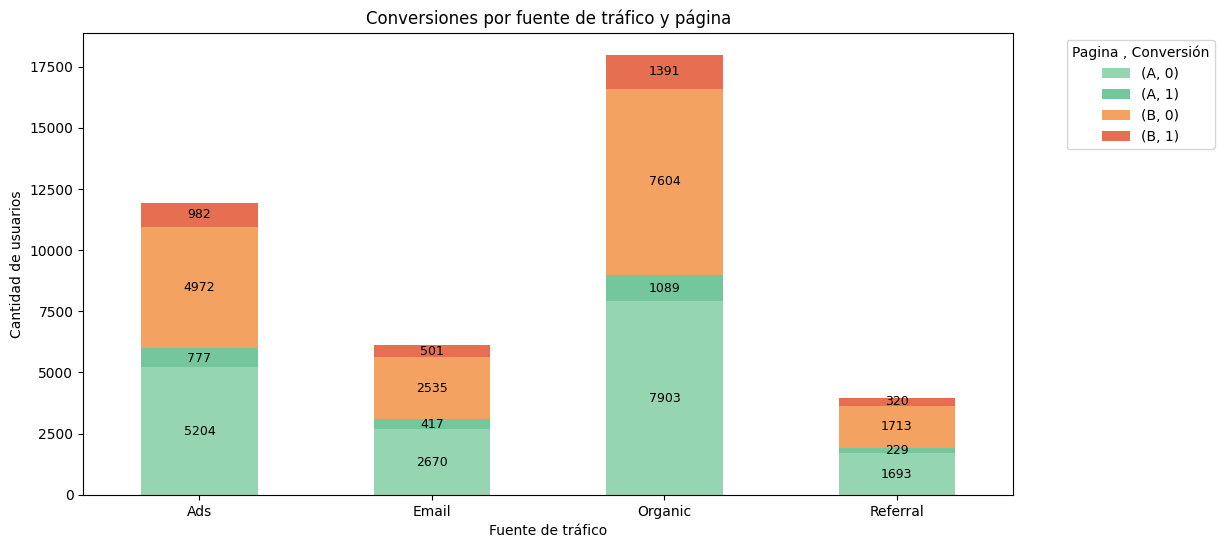

In [17]:
# Tabla cruzada
tabla = pd.crosstab(
    df['traffic_source'],
    [df['landing'], df['converted']]
)

#Paleta de colores
colores = ['#95D5B2', '#74C69D', '#F4A261', '#E76F51']

# Gráfico de barras apiladas
ax = tabla.plot(kind='bar', stacked=True, figsize=(12,6), color = colores)

# Agregar valores
for bar in ax.patches:
    height = bar.get_height()

    if height > 0:
        ax.text(x=bar.get_x() + bar.get_width()/2,
            y=bar.get_y() + height/2,
            s=int(height),
            ha='center',
            va='center',
            fontsize=9)

# Títulos
plt.title('Conversiones por fuente de tráfico y página')
plt.xlabel('Fuente de tráfico')
plt.ylabel('Cantidad de usuarios')

plt.legend(title='Pagina , Conversión',
           bbox_to_anchor=(1.05,1),
           loc='upper left')

plt.xticks(rotation=0)

plt.show()

✍️ **Comentario:**
- El análisis de conversiones por fuente de tráfico muestra que el canal Organic concentra el mayor volumen de conversiones, impulsado principalmente por su alto nivel de tráfico, con un desempeño consistente en ambas landings.

- Los canales Email y Ads presentan las tasas de conversión más altas, lo que indica una mayor calidad del tráfico y una mejor intención de los usuarios. En estos canales, la página B supera de forma consistente a la página A en número de conversiones.

- Por otro lado, Referral muestra el menor volumen de usuarios y conversiones, aunque mantiene el mismo patrón de comportamiento, con mayor rendimiento de la landing B.

- En conjunto, los resultados evidencian que tanto la fuente de tráfico como la página influyen en la conversión, destacando de forma consistente el mejor desempeño de la landing B en todos los canales analizados.

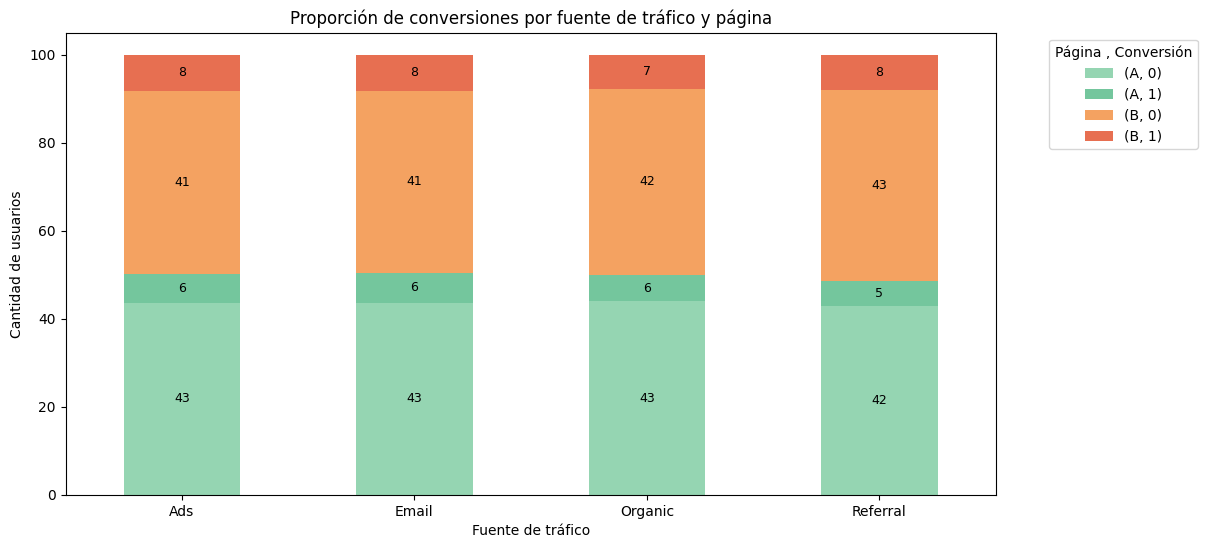

In [18]:
# Tabla cruzada
tabla = pd.crosstab(
    df['traffic_source'],
    [df['landing'], df['converted']],
    normalize='index'
) * 100

colores = ['#95D5B2', '#74C69D', '#F4A261', '#E76F51']
# Gráfico de barras apiladas
ax = tabla.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6),
    color = colores)

# Agregar valores
for bar in ax.patches:
    height = bar.get_height()

    if height > 0:
        ax.text(
            x=bar.get_x() + bar.get_width()/2,
            y=bar.get_y() + height/2,
            s=int(height),
            ha='center',
            va='center',
            fontsize=9
        )

# Títulos
plt.title('Proporción de conversiones por fuente de tráfico y página')
plt.xlabel('Fuente de tráfico')
plt.ylabel('Cantidad de usuarios')

plt.legend(title='Página , Conversión',
           bbox_to_anchor=(1.05,1),
           loc='upper left')

plt.xticks(rotation=0)

plt.show()

✍️ **Comentario:**
- La gráfica de proporciones muestra que, aunque las diferencias entre canales son relativamente pequeñas, la landing B mantiene una ventaja consistente en todos los casos. Esto sugiere que su mejor desempeño no depende de una fuente de tráfico específica, sino de características propias de la página.

- La fuente de tráfico Organic destaca por aportar el mayor volumen de usuarios, pero con una distribución proporcional más equilibrada entre conversiones y no conversiones, mientras que Ads y Email concentran proporciones de conversión ligeramente más favorables.

### Relación entre el tipo de usuario y la conversión

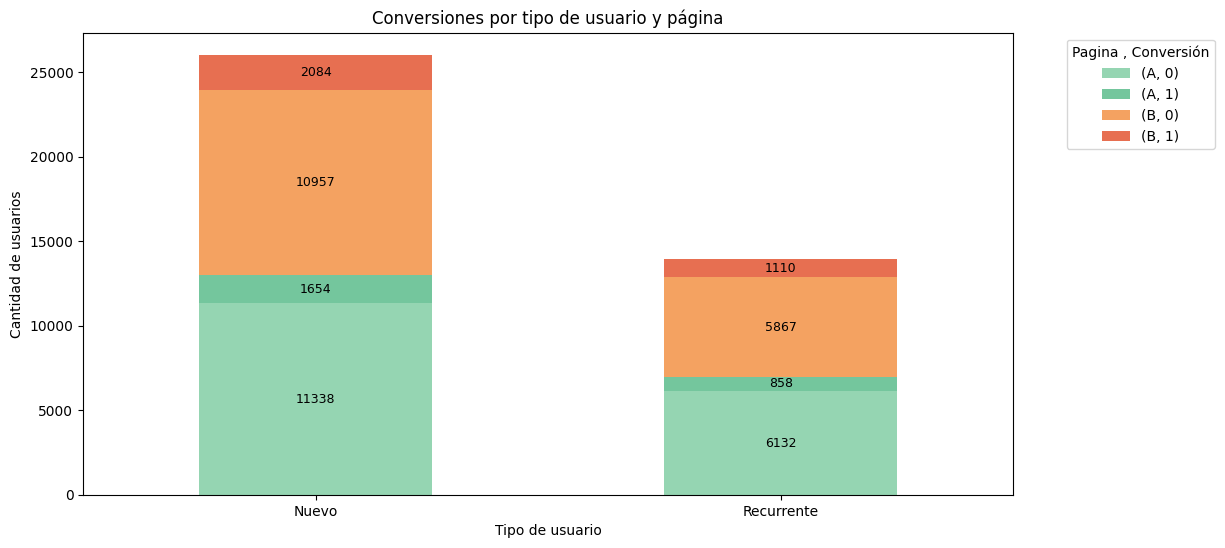

In [19]:
# Tabla cruzada
tabla = pd.crosstab(
    df['user_type'],
    [df['landing'], df['converted']]
)

#Paleta de colores
colores = ['#95D5B2', '#74C69D', '#F4A261', '#E76F51']

# Gráfico de barras apiladas
ax = tabla.plot(kind='bar', stacked=True, figsize=(12,6), color = colores)

# Agregar valores
for bar in ax.patches:
    height = bar.get_height()

    if height > 0:
        ax.text(x=bar.get_x() + bar.get_width()/2,
            y=bar.get_y() + height/2,
            s=int(height),
            ha='center',
            va='center',
            fontsize=9)

# Títulos
plt.title('Conversiones por tipo de usuario y página')
plt.xlabel('Tipo de usuario')
plt.ylabel('Cantidad de usuarios')

plt.legend(title='Pagina , Conversión',
           bbox_to_anchor=(1.05,1),
           loc='upper left')

plt.xticks(rotation=0)

plt.show()

✍️ **Comentario:**
- Para usuarios nuevos, la tasa de conversión aumentó aproximadamente de 12.7% en la versión A a 16.0% en la versión B. Esto representa una mejora importante en la capacidad de convertir visitantes por primera vez.

- En usuarios recurrentes también se observa una mejora similar. La variante B alcanzó una tasa de conversión cercana al 15.9%, mientras que la variante A se mantuvo alrededor del 12.3%.

- La gráfica muestra que no existe una relación significativa entre el tipo de usuario y las conversiones. Aunque visualmente los usuarios nuevos presentan un mayor número absoluto de conversiones, esto se debe principalmente a que el tamaño de ese grupo es mayor dentro de la muestra analizada.

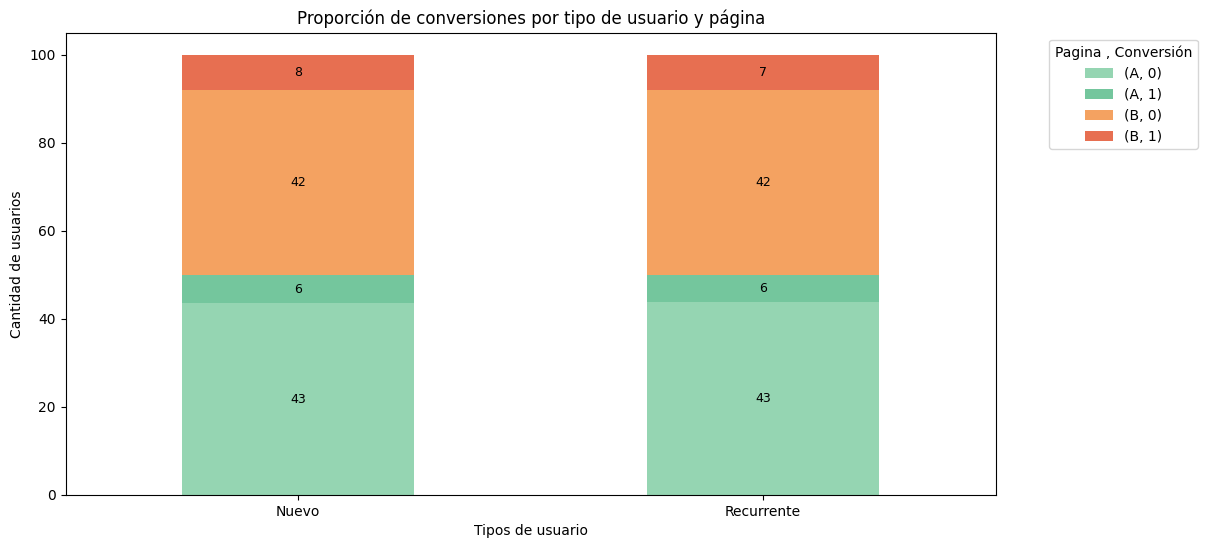

In [20]:

# Tabla cruzada
tabla = pd.crosstab(
    df['user_type'],
    [df['landing'], df['converted']],
normalize='index') * 100

#Paleta de colores
colores = ['#95D5B2', '#74C69D', '#F4A261', '#E76F51']

# Gráfico de barras apiladas
ax = tabla.plot(kind='bar', stacked=True, figsize=(12,6), color = colores)

# Agregar valores
for bar in ax.patches:
    height = bar.get_height()

    if height > 0:
        ax.text(x=bar.get_x() + bar.get_width()/2,
            y=bar.get_y() + height/2,
            s=int(height),
            ha='center',
            va='center',
            fontsize=9)

# Títulos
plt.title('Proporción de conversiones por tipo de usuario y página')
plt.xlabel('Tipos de usuario')
plt.ylabel('Cantidad de usuarios')

plt.legend(title='Pagina , Conversión',
           bbox_to_anchor=(1.05,1),
           loc='upper left')

plt.xticks(rotation=0)

plt.show()


✍️ **Comentario:**
- Se observa que la distribución de conversiones es prácticamente igual entre usuarios nuevos y recurrentes. En ambos casos, alrededor del 6–8% de los usuarios convierten, mientras que la mayoría permanece en la categoría de no conversión.

- La similitud entre las proporciones refuerza los resultados obtenidos en las pruebas estadísticas, donde no se encontró evidencia significativa de una relación entre el tipo de usuario y la conversión. Es decir, el comportamiento de conversión se mantiene estable independientemente de si el usuario es nuevo o recurrente.

- La gráfica permite ver que las diferencias observadas en cantidades absolutas de la gráfica anterior estaban influenciadas por el tamaño de cada grupo y no por una diferencia real en la probabilidad de convertir.

## 🧩 7. Insight Ejecutivo para Stakeholders

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
- El gasto promedio para los usuarios que convirtieron usando la Página A fue de 61.09, mientras que para la Página B ascendió a 68.75. Esto representa una diferencia absoluta de 7.66 a favor de la variante B.
- La prueba t-Student para muestras independientes arrojó un estadístico t de -9.37 y un p-valor extremadamente bajo de 1.06 x 10^{-20} (muy inferior al nivel de significancia de alpha = 0.05).
- **Interpretación:** Existe una diferencia altamente significativa desde el punto de vista estadístico. La nueva variante (Página B) no solo atrae conversiones, sino que incentiva un mayor desembolso económico por parte de los clientes, incrementando el ticket promedio de compra en un 12.54% en comparación con la versión de control.

<br>

**Tasa de conversión:**
- La Página A obtuvo una tasa de conversión del 12.57% (2,512 usuarios convertidos de un total de 19,982), en contraste con la Página B, que alcanzó un 15.96% (3,194 usuarios convertidos de un total de 20,018).
- La prueba Z de proporciones reportó un estadístico z de -9.68 y un p-valor de 3.76 x 10^{-22}, rechazando rotundamente la hipótesis nula.
- **Interpretación:** La Página B incrementó la probabilidad de conversión de manera genuina y estadísticamente validada, logrando un aumento neto de 3.38 puntos porcentuales (lo que se traduce en una mejora relativa del 26.97% en la efectividad de captura de registros/ventas).

---

#### 📊 **Segmentación por fuente de tráfico**
- La prueba de Chi-cuadrado de independencia determinó que la conversión está estadísticamente asociada al canal de entrada (Chi2 = 8.662, p-valor = 0.034). Las fuentes pagas y dirigidas registraron el mejor rendimiento relativo: Email (14.99%) y Ads (14.74%), superando a las fuentes Organic (13.79%) y Referral (13.88%).
- **Interpretación:** El canal Organic es el que arrastra el mayor volumen bruto de usuarios y conversiones por su tamaño general en el ecosistema. Sin embargo, el tráfico proveniente de Ads y Email demuestra una mayor intención de compra y calidad. Cabe destacar que el análisis visual confirma que la Página B mantuvo un rendimiento superior y una ventaja consistente sobre la Página A en todas las fuentes de tráfico analizadas.

 ---

#### 📊 **Segmentación por tipo de usuario**
- Al aplicar las pruebas de Chi-cuadrado (p = 0.474) y el Test Exacto de Fisher (p = 0.472), no se halló evidencia estadística para afirmar que la conversión dependa de si el usuario es Nuevo o Recurrente. Las tasas globales evaluadas fueron marginalmente idénticas: 14.4% para usuarios nuevos y 14.1% para recurrentes.
- **Interpretación:** El comportamiento de conversión se mantiene homogéneo independientemente de la familiaridad previa del usuario con la marca. No obstante, al aislar el efecto de la landing por segmento, se observa un incremento idéntico en el impacto de la variante: los usuarios nuevos saltaron de un 12.7% (A) a un 16.0% (B), y los recurrentes de un 12.3% (A) a un 15.9% (B). Esto ratifica que la Página B es superior transversalmente y su éxito no está sesgado por el tipo de usuario.

---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:**
- **Despliegue total de la variante B:** Se recomienda de manera concluyente implementar la Página B al 100% del tráfico de la plataforma. Esta decisión se encuentra plenamente respaldada por la combinación ganadora de un aumento significativo en la tasa de conversión (+26.97% relativo) y en el gasto promedio por cliente (+12.54% relativo), garantizando un impacto directo y positivo en la facturación global del negocio.
- **Optimización de la inversión en canales de tráfico:** Dado que los canales de Ads y Email demostraron poseer las tasas de conversión más eficientes y se ven fuertemente potenciados por el diseño de la Página B, se sugiere reasignar o incrementar el presupuesto de marketing hacia estas fuentes de tráfico calificado durante las próximas campañas, maximizando el Retorno de Inversión (ROI).
- **Campañas unificadas de captación:** Debido a la falta de asociación estadística entre el tipo de usuario y la conversión (ambos reaccionan igual de bien a la página B), el equipo de diseño y marketing no requiere duplicar esfuerzos construyendo páginas de aterrizaje hiper-segmentadas para públicos nuevos vs. recurrentes en esta etapa. Una estrategia de comunicación unificada bajo la estructura de la Página B mantendrá la máxima eficiencia de conversión.
- **Fase 2 de experimentación (Aislamiento de variables):** Tras asegurar este éxito comercial, se aconseja programar un experimento iterativo enfocado en descubrir los factores de éxito de la Página B (ej. mediante pruebas multivariantes o pruebas A/B de elementos específicos como el orden del formulario, textos del CTA o recursos visuales), con el fin de seguir desbloqueando puntos de conversión marginales.